In [1]:
import numpy as np
import subprocess
import os
import pandas as pd
import matplotlib.pyplot as plt


# from ICESEE.scripts.plotting.scaling_plots_csv_details import analyze_icesee
# from ICESEE.scripts.plotting.scaling_plots import plo
# 
# t_metrics,extract_metrics_from_log
from ICESEE.scripts.plotting.scaling_line_bar_plots import analyze_icesee

In [ ]:
def generate_latex_table(df, table_name, flag, output_file=None):
    """
    Generate a LaTeX table from a DataFrame for weak or strong scaling performance metrics.

    Parameters:
    df (pandas.DataFrame): DataFrame containing performance metrics with columns:
        - 'nodes': Number of nodes (integer)
        - 'ICESEE_ranks': Number of ICESEE ranks (integer)
        - 'ISSM_ranks': Number of ISSM ranks (integer)
        - 'Nens': Number of ensemble members (integer)
        - 'efficiency': Efficiency value (float)
        - 'speedup': Speedup value (float, required for strong scaling)
    table_name (str): Name or title for the table caption (LaTeX special characters should be escaped if necessary).
    flag (str): Type of scaling, either 'weak_scaling' or 'strong_scaling'.
    output_file (str, optional): Name of the output LaTeX file. If None, defaults to 'Weak_Scaling_Table.tex' for weak scaling
        or 'Strong_Scaling_Table.tex' for strong scaling.

    Returns:
    str: LaTeX code for the generated table.

    Raises:
    ValueError: If required columns are missing, DataFrame is empty, or flag is invalid.
    TypeError: If required columns have incorrect data types.
    IOError: If the output file cannot be written.
    """
    import pandas as pd

    # Validate flag
    valid_flags = ['weak_scaling', 'strong_scaling']
    if flag not in valid_flags:
        raise ValueError(f"Flag must be one of: {', '.join(valid_flags)}")

    # Set default output file based on flag
    if output_file is None:
        output_file = f"{flag.capitalize()}_Table.tex"

    # Define required columns based on flag
    required_columns = ['nodes', 'ICESEE_ranks', 'ISSM_ranks', 'Nens', 'time_m', 'efficiency']
    if flag == 'strong_scaling':
        required_columns.append('speedup')

    # Check if DataFrame is empty
    if df.empty:
        raise ValueError("DataFrame is empty")

    # Check for required columns
    if not all(col in df.columns for col in required_columns):
        raise ValueError(f"DataFrame must contain all required columns: {', '.join(required_columns)}")

    # Validate data types
    for col in ['nodes', 'ICESEE_ranks', 'ISSM_ranks', 'Nens']:
        if not pd.api.types.is_integer_dtype(df[col]):
            raise TypeError(f"Column '{col}' must contain integer values")
    for col in ['efficiency'] + (['speedup'] if flag == 'strong_scaling' else []):
        if not pd.api.types.is_float_dtype(df[col]):
            raise TypeError(f"Column '{col}' must contain float values")

    # Escape LaTeX special characters in table_name
    def escape_latex(text):
        """Escape LaTeX special characters in a string."""
        latex_special_chars = {
            '&': r'\&', '%': r'\%', '$': r'\$', '#': r'\#', '_': r'\_',
            '{': r'\{', '}': r'\}', '~': r'\textasciitilde{}', '^': r'\textasciicircum{}',
            '\\': r'\textbackslash{}'
        }
        return ''.join(latex_special_chars.get(c, c) for c in str(text))

    table_name_escaped = escape_latex(table_name)

    # Start LaTeX document
    latex_content = r"""\documentclass{article}
\usepackage{booktabs}
\usepackage{amsmath}
\usepackage{siunitx}
\begin{document}

\begin{table}[ht]
\centering
\caption{""" + (r"Weak Scaling " if flag == "weak_scaling" else r"Strong Scaling ") + table_name_escaped + r"""}
\begin{tabular}{ccccc S[table-format=2.2]""" + (r" S[table-format=2.2]" if flag == "strong_scaling" else "") + r"""}
\toprule
{Nodes} & {ICESEE Ranks} & {ISSM Ranks} & {$N_{\text{ens}}$} &  {Wall Time} & {Efficiency}""" + (r" & {Speedup}" if flag == "strong_scaling" else "") + r""" \\
\midrule
"""

    # Add table rows
    for _, row in df[required_columns].iterrows():
        nodes = row['nodes']
        icesee_ranks = row['ICESEE_ranks']
        issm_ranks = row['ISSM_ranks']
        nens = row['Nens']
        time_m = f"{row['time_m']:.2f}"
        efficiency = f"{row['efficiency']:.2f}"
        if flag == "weak_scaling":
            latex_content += f"{nodes} & {icesee_ranks} & {issm_ranks} & {nens} & {time_m} & {efficiency} \\\\\n"
        else:
            speedup = f"{row['speedup']:.2f}"
            latex_content += f"{nodes} & {icesee_ranks} & {issm_ranks} & {nens} & {time_m} & {efficiency} & {speedup} \\\\\n"

    # Close LaTeX table and document
    latex_content += r"""\bottomrule
\end{tabular}
\end{table}

\end{document}
"""

    # Write to file with error handling
    try:
        with open(output_file, 'w') as f:
            f.write(latex_content)
    except IOError as e:
        raise IOError(f"Failed to write LaTeX file '{output_file}': {str(e)}")

    return latex_content

def form_new_columns(df,model_np,node_size,baseline_nens,flag):
    ICESEE_ranks = df['ranks'].values*(model_np+1)
    ISSM_ranks = model_np
    df['ICESEE_ranks'] = ICESEE_ranks
    df['ISSM_ranks'] = ISSM_ranks
    df['nodes'] = [1 if rank < node_size else int(np.ceil(rank / node_size)) for rank in ICESEE_ranks]
    if flag=="strong_scaling":
        nens_strong = baseline_nens*np.ones_like(ICESEE_ranks)
        df['Nens'] = nens_strong
        return df.copy()[['nodes', 'ICESEE_ranks', 'ISSM_ranks', 'Nens', 'time_m', 'speedup', 'efficiency']]
    elif flag=="weak_scaling":
        nens_weak = baseline_nens*df['ranks'].values
        df['Nens'] = nens_weak
        return  df.copy()[['nodes', 'ICESEE_ranks', 'ISSM_ranks', 'Nens', 'time_m', 'efficiency']]

: 

In [ ]:
model_np=4
analyze_icesee("strong_scaling_o.log", scaling_type="strong_scaling", model_np=model_np)

/Users/bkyanjo3/da_project/ICESEE/scripts/plotting/scaling_line_bar_plots.py:297: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{N:.0f}" for N in ax.get_yticks()], fontsize=20, fontweight="bold")


{'outputs_dir': '/Users/bkyanjo3/da_project/ICESEE/applications/issm_model/examples/ISMIP_Choi/icesee_perf_outputs',
 'csvs': ['icesee_perf_outputs/strong_scaling_wallclock_scaling.csv',
  'icesee_perf_outputs/strong_scaling_forecast_scaling.csv',
  'icesee_perf_outputs/strong_scaling_raw_times.csv'],
 'plots': ['icesee_perf_outputs/strong_scaling_analysis_efficiency.png',
  'icesee_perf_outputs/strong_scaling_analysis_speedup.png',
  'icesee_perf_outputs/strong_scaling_forecast_efficiency.png',
  'icesee_perf_outputs/strong_scaling_forecast_speedup.png',
  'icesee_perf_outputs/strong_scaling_io_efficiency.png',
  'icesee_perf_outputs/strong_scaling_io_speedup.png',
  'icesee_perf_outputs/strong_scaling_stacked_breakdown.png',
  'icesee_perf_outputs/strong_scaling_wallclock_efficiency.png',
  'icesee_perf_outputs/strong_scaling_wallclock_speedup.png',
  'icesee_perf_outputs/weak_scaling_analysis_efficiency.png',
  'icesee_perf_outputs/weak_scaling_analysis_speedup.png',
  'icesee_perf_

: 

In [ ]:
path = 'icesee_perf_outputs/strong_scaling_wallclock_scaling.csv'
df = pd.read_csv(path)
df = form_new_columns(df,model_np=4,node_size=24,baseline_nens=64,flag="strong_scaling")
generate_latex_table(df, table_name="Wallclock", flag="strong_scaling", output_file="Strong_Scaling_wallclock_Table.tex")
df

,nodes,ICESEE_ranks,ISSM_ranks,Nens,time_m,speedup,efficiency
0,1,5,4,64,695.689933,1.000000,100.000000
1,1,10,4,64,365.011100,1.905942,95.297093
2,1,20,4,64,206.845633,3.363329,84.083227
3,2,40,4,64,116.549533,5.969049,74.613119
4,4,80,4,64,81.312117,8.555797,53.473729
5,7,160,4,64,44.273750,15.713373,49.104290
6,14,320,4,64,26.057017,26.698756,41.716806


: 

In [ ]:
path = 'icesee_perf_outputs/strong_scaling_forecast_scaling.csv'
df = pd.read_csv(path)
df = form_new_columns(df,model_np=4,node_size=24,baseline_nens=64,flag="strong_scaling")
generate_latex_table(df,table_name="Forecast", flag="strong_scaling",output_file="Strong_Scaling_Forecast_Table.tex")
df


,nodes,ICESEE_ranks,ISSM_ranks,Nens,time_m,speedup,efficiency
0,1,5,4,64,605.613900,1.000000,100.000000
1,1,10,4,64,308.987633,1.959994,97.999699
2,1,20,4,64,173.213733,3.496339,87.408470
3,2,40,4,64,87.984050,6.883224,86.040297
4,4,80,4,64,53.739733,11.269388,70.433674
5,7,160,4,64,32.913067,18.400409,57.501279
6,14,320,4,64,18.912733,32.021490,50.033578


: 

In [ ]:
path = 'icesee_perf_outputs/strong_scaling_analysis_scaling.csv'
df = pd.read_csv(path)
df = form_new_columns(df,model_np=4,node_size=24,baseline_nens=64,flag="strong_scaling")
generate_latex_table(df, table_name="Analysis", flag="strong_scaling", output_file="Strong_Scaling_analysis_Table.tex")
df

,nodes,ICESEE_ranks,ISSM_ranks,Nens,time_m,speedup,efficiency
0,1,5,4,64,61.791800,1.000000,100.000000
1,1,10,4,64,35.211217,1.754890,87.744483
2,1,20,4,64,20.886033,2.958523,73.963063
3,2,40,4,64,13.691400,4.513183,56.414793
4,4,80,4,64,8.512283,7.259133,45.369584
5,7,160,4,64,5.240950,11.790191,36.844346
6,14,320,4,64,3.023867,20.434697,31.929215


: 

In [ ]:
path = 'icesee_perf_outputs/strong_scaling_io_scaling.csv'
df = pd.read_csv(path)
df = form_new_columns(df,model_np=4,node_size=24,baseline_nens=64,flag="strong_scaling")
generate_latex_table(df, table_name="I/O", flag="strong_scaling", output_file="Strong_Scaling_io_Table.tex")
df

,nodes,ICESEE_ranks,ISSM_ranks,Nens,time_m,speedup,efficiency
0,1,5,4,64,57.684433,1.000000,100.000000
1,1,10,4,64,39.255067,1.469477,73.473870
2,1,20,4,64,28.064983,2.055388,51.384703
3,2,40,4,64,16.936550,3.405914,42.573925
4,4,80,4,64,9.785400,5.894949,36.843431
5,7,160,4,64,7.685233,7.505879,23.455873
6,14,320,4,64,4.151850,13.893670,21.708859


: 

In [ ]:
analyze_icesee("weak_scaling_o.log", scaling_type="weak_scaling", model_np=model_np)

/Users/bkyanjo3/da_project/ICESEE/scripts/plotting/scaling_line_bar_plots.py:297: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{N:.0f}" for N in ax.get_yticks()], fontsize=20, fontweight="bold")


{'outputs_dir': '/Users/bkyanjo3/da_project/ICESEE/applications/issm_model/examples/ISMIP_Choi/icesee_perf_outputs',
 'csvs': ['icesee_perf_outputs/weak_scaling_wallclock_scaling.csv',
  'icesee_perf_outputs/weak_scaling_forecast_scaling.csv',
  'icesee_perf_outputs/weak_scaling_raw_times.csv'],
 'plots': ['icesee_perf_outputs/strong_scaling_analysis_efficiency.png',
  'icesee_perf_outputs/strong_scaling_analysis_speedup.png',
  'icesee_perf_outputs/strong_scaling_forecast_efficiency.png',
  'icesee_perf_outputs/strong_scaling_forecast_speedup.png',
  'icesee_perf_outputs/strong_scaling_io_efficiency.png',
  'icesee_perf_outputs/strong_scaling_io_speedup.png',
  'icesee_perf_outputs/strong_scaling_stacked_breakdown.png',
  'icesee_perf_outputs/strong_scaling_wallclock_efficiency.png',
  'icesee_perf_outputs/strong_scaling_wallclock_speedup.png',
  'icesee_perf_outputs/weak_scaling_analysis_efficiency.png',
  'icesee_perf_outputs/weak_scaling_analysis_speedup.png',
  'icesee_perf_output

: 

In [ ]:
path = 'icesee_perf_outputs/weak_scaling_wallclock_scaling.csv'
df = pd.read_csv(path)
df = form_new_columns(df,model_np=4,node_size=24,baseline_nens=8,flag="weak_scaling")
generate_latex_table(df, table_name="Wallclock", flag="weak_scaling", output_file="Weak_Scaling_wallclock_Table.tex")
df

,nodes,ICESEE_ranks,ISSM_ranks,Nens,time_m,efficiency
0,1,5,4,8,78.555350,100.000000
1,1,10,4,16,81.589950,96.280669
2,1,20,4,32,83.376000,94.218180
3,2,40,4,64,89.922067,87.359369
4,4,80,4,128,97.902050,80.238718
5,7,160,4,256,108.901683,72.134193
6,14,320,4,512,127.868467,61.434498


: 

In [ ]:
path = 'icesee_perf_outputs/weak_scaling_forecast_scaling.csv'
df = pd.read_csv(path)
df = form_new_columns(df,model_np=4,node_size=24,baseline_nens=8,flag="weak_scaling")

generate_latex_table(df, table_name="Forecast", flag="weak_scaling", output_file="Weak_Scaling_Forecast_Table.tex")
df


,nodes,ICESEE_ranks,ISSM_ranks,Nens,time_m,efficiency
0,1,5,4,8,68.072917,100.000000
1,1,10,4,16,72.952767,93.310946
2,1,20,4,32,74.543200,91.320089
3,2,40,4,64,79.660867,85.453397
4,4,80,4,128,84.502867,80.556932
5,7,160,4,256,90.346200,75.346740
6,14,320,4,512,99.834533,68.185741


: 

In [ ]:
path = 'icesee_perf_outputs/weak_scaling_analysis_scaling.csv'
df = pd.read_csv(path)
df = form_new_columns(df,model_np=4,node_size=24,baseline_nens=8,flag="weak_scaling")
generate_latex_table(df,table_name="Analysis", flag="weak_scaling", output_file="Weak_Scaling_analysis_Table.tex")
df

,nodes,ICESEE_ranks,ISSM_ranks,Nens,time_m,efficiency
0,1,5,4,8,0.740200,100.000000
1,1,10,4,16,0.824267,89.801035
2,1,20,4,32,1.082433,68.382964
3,2,40,4,64,2.131650,34.724275
4,4,80,4,128,3.287650,22.514562
5,7,160,4,256,5.220350,14.179126
6,14,320,4,512,7.020850,10.542883


: 

In [ ]:
path = 'icesee_perf_outputs/weak_scaling_io_scaling.csv'
df = pd.read_csv(path)
df = form_new_columns(df,model_np=4,node_size=24,baseline_nens=8,flag="weak_scaling")
generate_latex_table(df, table_name="I/O", flag="weak_scaling", output_file="Weak_Scaling_io_Table.tex")
df

,nodes,ICESEE_ranks,ISSM_ranks,Nens,time_m,efficiency
0,1,5,4,8,0.730183,100.000000
1,1,10,4,16,0.889633,82.076886
2,1,20,4,32,1.517900,48.104838
3,2,40,4,64,4.035300,18.094896
4,4,80,4,128,8.202133,8.902359
5,7,160,4,256,10.875350,6.714113
6,14,320,4,512,13.981300,5.222571


: 

In [ ]:
# generate pdf's for all formed latex tables
  # List of LaTeX files to process
tex_files = [
    "Weak_Scaling_Table.tex",
    "Weak_Scaling_wallclock_Table.tex",
    "Weak_Scaling_Forecast_Table.tex",
    "Weak_Scaling_analysis_Table.tex",
    "Weak_Scaling_io_Table.tex",
    "Strong_Scaling_Table.tex",
    "Strong_Scaling_wallclock_Table.tex",
    "Strong_Scaling_Forecast_Table.tex",
    "Strong_Scaling_analysis_Table.tex",
    "Strong_Scaling_io_Table.tex"
]
for tex_file in tex_files:
    if os.path.exists(tex_file):
        try:
            subprocess.run(['pdflatex', tex_file], check=True)
            print(f"Successfully compiled {tex_file} to PDF.")
        except subprocess.CalledProcessError as e:
            print(f"Error compiling {tex_file}: {e}")

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025/Homebrew) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode
(./Weak_Scaling_Table.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>

(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/base/articl
e.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class

(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/base/size10
.clo))
(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/booktabs/bo
oktabs.sty)
(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/amsmath/ams
math.sty
For additional information on amsmath, use the `?' option.

(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/amsmath/ams
text.sty
(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/amsmath/ams
gen.sty))
(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/amsmath/ams
bsy.s

: 

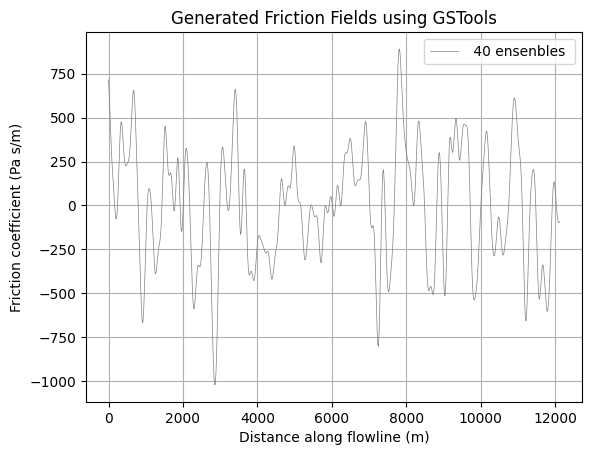

friction std: [0. 0. 0. ... 0. 0. 0.]


: 

In [ ]:
sill_friction= 90000      # Sill friction coefficient (90000 Pa s/m from paper)
range_friction= 5000      # Range friction coefficient (5000 Pa s/m from paper)
mean_friction= 2500       # Mean friction coefficient (2500 Pa s/m from paper)
nugget_friction= 0        # Nugget effect for friction (0 Pa s/m from paper)
sill_bed= 4000            # Sill bedrock elevation (4000 m from paper)
range_bed= 50000          # Range bedrock elevation (50000 m from paper)
nugget_bed= 200           # Nugget effect for bedrock elevation (200 m from paper)

nd = 36369

import gstools as gs
import numpy as np
import matplotlib.pyplot as plt
nens =40
seed_base=42
friction_field = []
# for ens in range(nens):
ens = 0
var_fric = max(sill_friction - nugget_friction, 0.0)
friction_model = gs.Gaussian(dim=1, var=var_fric, len_scale=range_friction, nugget=nugget_friction)

# friction_srf = gs.SRF(friction_model, mean=mean_friction, seed=seed_base + ens)
friction_srf = gs.SRF(friction_model, mean=0, seed=seed_base + ens)
# friction_srf = gs.SRF(friction_model, mean=0, seed=42)
fdim = nd//3
# x = np.linspace(0, range_friction, fdim)
x = np.linspace(0,640e3,fdim)
y = np.linspace(0,80e3,fdim)
# _friction_field = friction_srf.structured([x])
_friction_field =np.asarray(friction_srf.structured([x])).reshape(-1)
friction_field.append(_friction_field)
plt.plot(_friction_field, lw=0.5, color='gray', label=f" {nens} ensenbles " if ens==0 else "")
# plt.plot(_friction_field, lw=0.5, color='gray', label=f" {nens} ensenbles " if ens==0 else "")


# compute the mean friction field
# friction_field = np.array(friction_field)
# friction_mean = np.mean(friction_field, axis=0)
# plt.plot(friction_mean, lw=2, color='red', label='Mean friction field')
plt.xlabel('Distance along flowline (m)')
plt.ylabel('Friction coefficient (Pa s/m)')
plt.title('Generated Friction Fields using GSTools')
plt.legend()
plt.grid()
plt.show()
# print(f"max friction: {np.max(friction_field)}, min friction: {np.min(friction_field)}")
# friction_srf.plot()
# plot friction fields
# for ens
friction_std = np.std(friction_field, axis=0)
print(f"friction std: {friction_std}")

: 

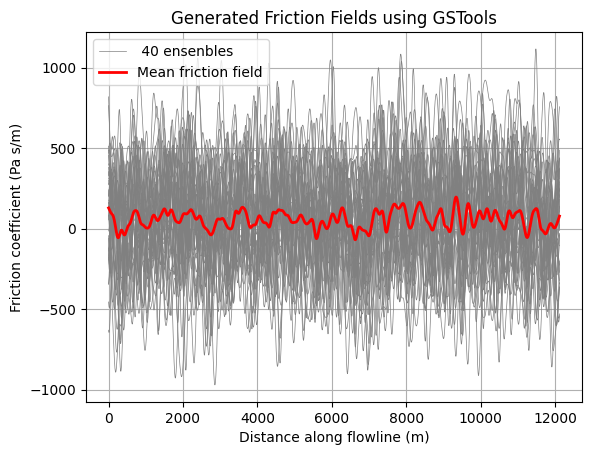

friction std: [313.93086503 313.46234495 312.95297447 ... 306.09657685 305.75880325
 305.4336095 ]


: 

In [ ]:
sill_friction= 90000      # Sill friction coefficient (90000 Pa s/m from paper)
range_friction= 5000      # Range friction coefficient (5000 Pa s/m from paper)
mean_friction= 2500       # Mean friction coefficient (2500 Pa s/m from paper)
nugget_friction= 0        # Nugget effect for friction (0 Pa s/m from paper)
sill_bed= 4000            # Sill bedrock elevation (4000 m from paper)
range_bed= 50000          # Range bedrock elevation (50000 m from paper)
nugget_bed= 200           # Nugget effect for bedrock elevation (200 m from paper)

nd = 36369

import gstools as gs
import numpy as np
import matplotlib.pyplot as plt
nens =40
seed_base=42
friction_field = []
for ens in range(nens):
    var_fric = max(sill_friction - nugget_friction, 0.0)
    friction_model = gs.Gaussian(dim=1, var=var_fric, len_scale=range_friction, nugget=nugget_friction)

    # friction_srf = gs.SRF(friction_model, mean=mean_friction, seed=seed_base + ens)
    friction_srf = gs.SRF(friction_model, mean=50, seed=seed_base + ens)
    # friction_srf = gs.SRF(friction_model, mean=0, seed=42)
    fdim = nd//3
    # x = np.linspace(0, range_friction, fdim)
    x = np.linspace(0,640e3,fdim)
    # _friction_field = friction_srf.structured([x])
    _friction_field =np.asarray(friction_srf.structured([x])).reshape(-1)
    friction_field.append(_friction_field)
    plt.plot(_friction_field, lw=0.5, color='gray', label=f" {nens} ensenbles " if ens==0 else "")

# compute the mean friction field
friction_field = np.array(friction_field)
friction_mean = np.mean(friction_field, axis=0)
plt.plot(friction_mean, lw=2, color='red', label='Mean friction field')
plt.xlabel('Distance along flowline (m)')
plt.ylabel('Friction coefficient (Pa s/m)')
plt.title('Generated Friction Fields using GSTools')
plt.legend()
plt.grid()
plt.show()
# print(f"max friction: {np.max(friction_field)}, min friction: {np.min(friction_field)}")
# friction_srf.plot()
# plot friction fields
# for ens
friction_std = np.std(friction_field, axis=0)
print(f"friction std: {friction_std}")

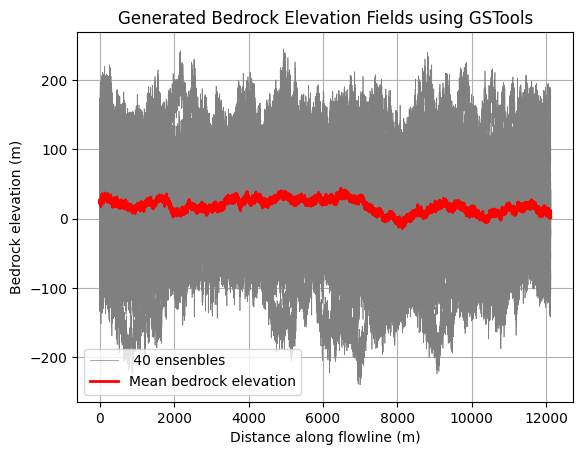

: 

In [ ]:
bed_field = []
for ens in range(nens):
    var_bed = max(sill_bed - nugget_bed, 0.0)
    bed_model = gs.Exponential(dim=1, var=var_bed, len_scale=range_bed, nugget=nugget_bed)

    bed_srf = gs.SRF(bed_model, mean=20, seed=seed_base + 10_000 + ens)   # different stream
    _bed_field = np.asarray(bed_srf.structured([x])).reshape(-1)  #+ np.random.normal(scale=20, size=_friction_field.shape)

    x = np.linspace(0, 640_000, fdim) 
    # _bed_field = bed_srf.unstructured([x])
    bed_field.append(_bed_field)
    # print(f"max bed: {np.max(_bed_field)}, min bed: {np.min(_bed_field)}")
    plt.plot(_bed_field, lw=0.5, color='gray', label=f" {nens} ensenbles " if ens==0 else "")

bed_field = np.array(bed_field)
bed_mean = np.mean(bed_field, axis=0)
plt.plot(bed_mean, lw=2, color='red', label='Mean bedrock elevation')
plt.xlabel('Distance along flowline (m)')
plt.ylabel('Bedrock elevation (m)')
plt.title('Generated Bedrock Elevation Fields using GSTools')
plt.legend()
plt.grid()
plt.show()




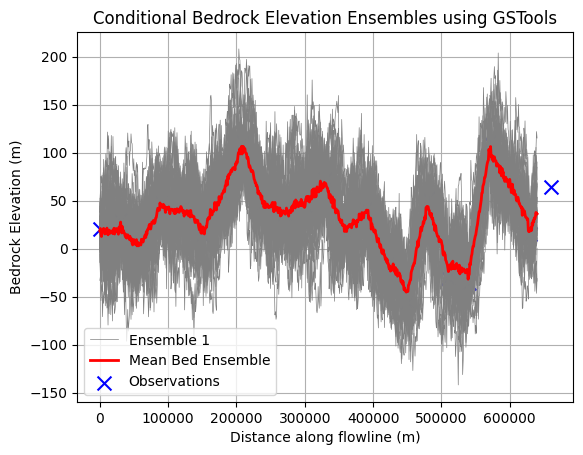

: 

In [ ]:
import numpy as np
import gstools as gs

# ---------------------------------------------------
# Domain setup
# ---------------------------------------------------
Lx = 640e3          # 640 km
fdim = 800          # number of grid points along x
x = np.linspace(0, Lx, fdim)

# ---------------------------------------------------
# Covariance parameters (from Gillet-Chaulet 2020)
# ---------------------------------------------------
sill_bed   = 4000.0     # m^2 total
nugget_bed = 200.0      # m^2
range_bed  = 50e3       # m
var_bed    = sill_bed - nugget_bed

model_bed = gs.Exponential(dim=1, var=var_bed, len_scale=range_bed, nugget=nugget_bed)

# ---------------------------------------------------
# Synthetic radar measurements every 30 km
# ---------------------------------------------------
track_spacing = 30e3
x_obs = np.arange(0.0, Lx + track_spacing, track_spacing)

# Create a "true" bed field to sample observations
srf_true = gs.SRF(model_bed, mean=0.0, seed=123)
bed_true = srf_true.structured([x])
ix_obs = np.searchsorted(x, x_obs)
ix_obs = np.clip(ix_obs, 0, len(x) - 1)
bed_obs = bed_true[ix_obs] + np.random.normal(0.0, np.sqrt(nugget_bed), size=len(x_obs))

# ---------------------------------------------------
# Build kriging object for conditional simulations
# ---------------------------------------------------
# positions must be shape (dim, n_obs)
cond_pos = np.array([x_obs])
cond_val = bed_obs
krige_bed = gs.krige.Ordinary(model_bed, cond_pos, cond_val)

# ---------------------------------------------------
# Generate conditional ensembles
# ---------------------------------------------------
n_ens = 40
bed_ens = np.empty((n_ens, fdim))

for k in range(n_ens):
    # CondSRF now takes the krige object, not the model directly
    srf_cond = gs.CondSRF(krige_bed, seed=20_000 + k)
    bed_ens[k, :] = srf_cond.structured([x])
    plt.plot(x, bed_ens[k, :], lw=0.5, color='gray', label=f"Ensemble {k+1}" if k==0 else "")

mean_bed_ens = np.mean(bed_ens, axis=0)
plt.plot(x, mean_bed_ens, lw=2, color='red', label='Mean Bed Ensemble')
plt.scatter(x_obs, bed_obs, color='blue', marker='x', s=100, label='Observations')
plt.xlabel('Distance along flowline (m)')
plt.ylabel('Bedrock Elevation (m)')
plt.title('Conditional Bedrock Elevation Ensembles using GSTools')
plt.legend()
plt.grid()
plt.show()

# ---------------------------------------------------
# Optional mean offset (if you want absolute elevations)
# ---------------------------------------------------
bed_ens += -200.0  # shift to e.g. -200 m mean bed level

In [ ]:
import h5py

with h5py.File('_modelrun_datasets/ensemble_output_0.h5', 'r') as f:
    bed = f['bed'][0]
    friction_field = f['coefficient'][0]
    print(bed.shape)
    print(friction_field.shape)


(12323,)
(12323,)


: 

In [ ]:
#  create and write bed observations to h5 file
import h5py
import numpy as np
import gstools as gs

# ---------------------------------------------------
# Synthetic radar measurements every 30 km
# ---------------------------------------------------
Lx = 640e3
sill_bed   = 4000.0     # m^2 total
nugget_bed = 200.0      # m^2
range_bed  = 50e3       # m
track_spacing = 30e3
fdim = 12323     # number of grid points along x

x_obs = np.arange(0.0, Lx + track_spacing, track_spacing)
x = np.linspace(0, Lx, fdim)
var_bed    = sill_bed - nugget_bed

model_bed = gs.Exponential(dim=1, var=var_bed, len_scale=range_bed, nugget=nugget_bed)

# get true bed field from file
with h5py.File('_modelrun_datasets/true_nurged_states.h5', 'r') as f:
    bed_true = f['true_state'][fdim:2*fdim,0]

# use true bed field to sample observations
ix_obs = np.searchsorted(x, x_obs)
ix_obs = np.clip(ix_obs, 0, len(x) - 1)
bed_obs = bed_true[ix_obs] + np.random.normal(0.0, np.sqrt(nugget_bed), size=len(x_obs))
print(bed_obs.shape)

# build a kringing object for conditional simulations
# positions must be shape (dim, n_obs)
cond_pos = np.array([x_obs])
cond_val = bed_obs
krige_bed = gs.krige.Ordinary(model_bed, cond_pos, cond_val)
srf_cond = gs.CondSRF(krige_bed, seed=20_000)
bed_ens = srf_cond.structured([x])
print(bed_ens.shape)


(23,)
(12323,)


: 

In [ ]:
import h5py
file_path = '_modelrun_datasets/true_nurged_states.h5'
with h5py.File(file_path, 'r') as f:
   true = f['true_state'][:, :]
   nurged = f['nurged_state'][:, :]
print(true.shape)

(61615, 101)


: 

: 

friction field shape: (12323,)


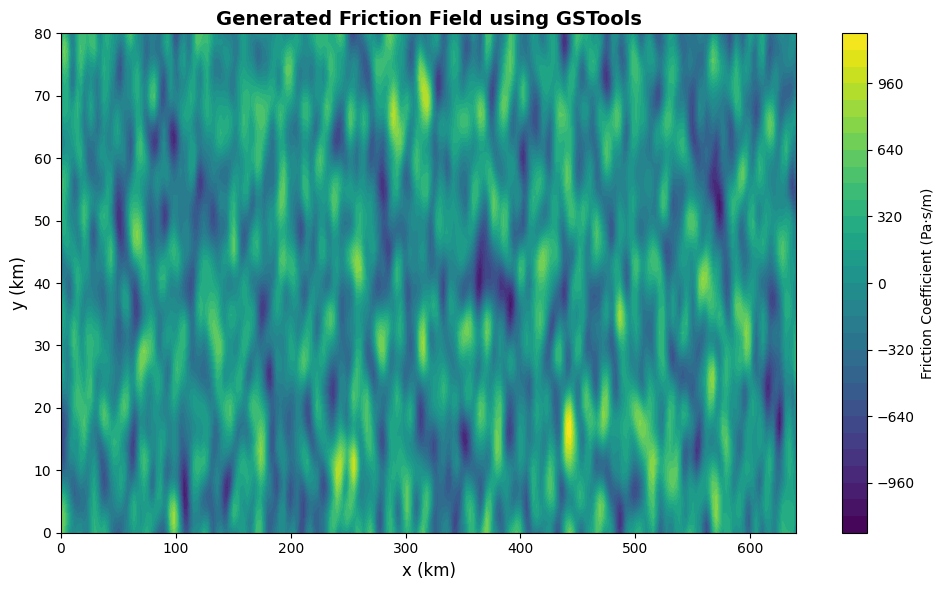

In [1]:
import gstools as gs
import numpy as np

nd = 12323
nx, ny = 222, 56
Lx = 640e3
Ly = 80e3
x = np.linspace(0, 640e3, nx)
y = np.linspace(0, 80e3, ny)
xx, yy = np.meshgrid(x, y, indexing='ij')

# friction field
sill_friction= 90000      # Sill friction coefficient (90000 Pa s/m from paper)
range_friction= 5000      # Range friction coefficient (5000 Pa s/m from paper)
mean_friction= 2500       # Mean friction coefficient (2500 Pa s/m from paper)
nugget_friction= 0        # Nugget effect for friction (0 Pa s/m from paper)

# bed field
sill_bed= 4000            # Sill bedrock elevation (4000 m from paper)
range_bed= 50000          # Range bedrock elevation (50000 m from paper)
nugget_bed= 200           # Nugget effect for bedrock elevation (200 m from paper)

seed = 42


model = gs.Gaussian(dim=2, var=sill_friction, len_scale=range_friction)
srf = gs.SRF(model, seed=seed)
field_2d = srf((x, y), mesh_type='structured')
# flatten friction field
friction_field = field_2d.reshape(-1)[:nd]
fmean = mean_friction*np.ones_like(friction_field) + friction_field
print(f"friction field shape: {fmean.shape}")

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
contour = plt.contourf(xx / 1e3, yy / 1e3, field_2d, levels=30, cmap='viridis')
plt.colorbar(contour, label='Friction Coefficient (Pa·s/m)')
plt.xlabel('x (km)', fontsize=12)
plt.ylabel('y (km)', fontsize=12)
plt.title('Generated Friction Field using GSTools', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

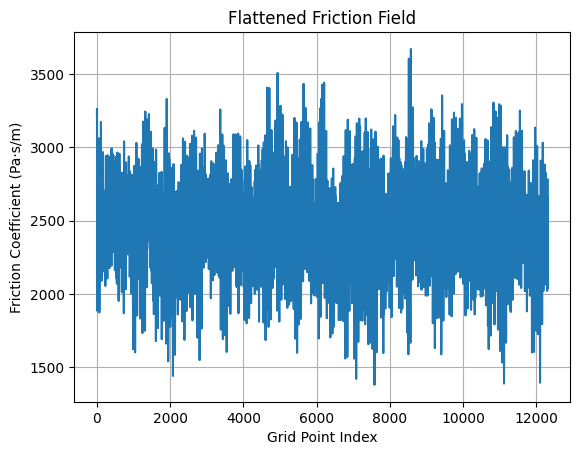

In [2]:
# flatten friction field
plt.plot(fmean)
plt.xlabel('Grid Point Index')
plt.ylabel('Friction Coefficient (Pa·s/m)')
plt.title('Flattened Friction Field')
plt.grid()
plt.show()

In [3]:
def generate_bed_observations(Lx=640e3, Ly=80e3, nx=222, ny=56,
                              range_bed=50e3, sill_bed=4e3, nugget_bed=200,
                              track_spacing=30e3, noise_std=5.0, seed=42):
    """
    Generate synthetic 2D bed topography field and radar observations along tracks.
    
    Parameters
    ----------
    Lx, Ly : float
        Domain size in meters.
    nx, ny : int
        Number of grid points in x and y directions.
    range_bed, sill_bed, nugget_bed : float
        Parameters of the exponential variogram.
    track_spacing : float
        Distance between radar tracks (in meters) perpendicular to flow.
    noise_std : float
        Standard deviation of Gaussian noise added to observations (in meters).
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    bed_true : ndarray (nx, ny)
        True bed topography field over the full domain.
    obs_pos : ndarray (N_obs, 2)
        Coordinates (x, y) of radar observation points.
    obs_val : ndarray (N_obs,)
        Observed bed elevations with noise.
    grid_x, grid_y : 1D arrays
        Coordinate vectors for plotting or conditioning.
    """
    rng = np.random.default_rng(seed)
    x = np.linspace(0, Lx, nx)
    y = np.linspace(0, Ly, ny)
    xx, yy = np.meshgrid(x, y, indexing="ij")

    # --- Define exponential covariance model for bed ---
    model_bed = gs.Exponential(dim=2, var=sill_bed, len_scale=range_bed, nugget=nugget_bed)
    srf_bed = gs.SRF(model_bed, seed=seed)
    
    # --- Generate true 2D bed field ---
    bed_true = srf_bed((x, y), mesh_type='structured')

    # --- Radar observation tracks perpendicular to x-direction (ice flow) ---
    track_y = np.arange(0, Ly + track_spacing, track_spacing)
    obs_x = np.linspace(0, Lx, nx)
    obs_coords = [(xv, yv) for yv in track_y for xv in obs_x if yv <= Ly]
    obs_coords = np.array(obs_coords)
    
    # --- Extract true bed values at observation points ---
    obs_val_true = srf_bed(obs_coords.T)
    
    # --- Add Gaussian measurement noise ---
    obs_val = obs_val_true + rng.normal(0, noise_std, obs_val_true.shape)
    
    return bed_true, obs_coords, obs_val, x, y


In [4]:
bed_true, obs_coords, obs_val, x,y = generate_bed_observations(Lx=Lx, Ly=Ly, nx=nx, ny=ny,
                                                             range_bed=range_bed, sill_bed=sill_bed, nugget_bed=nugget_bed,
                                                             track_spacing=30e3, noise_std=5.0, seed=42)

In [ ]:
# --- Define covariance model (Exponential) ---
model_bed = gs.Exponential(dim=2, var=sill_bed, len_scale=range_bed, nugget=nugget_bed)
srf_bed = gs.SRF(model_bed, seed=seed)
bed_true = srf_bed((x, y), mesh_type='structured')

# --- Simulate radar tracks every 30 km across the domain ---
track_spacing = 30e3
track_y = np.arange(0, Ly + track_spacing, track_spacing)
obs_x = np.linspace(0, Lx, nx)
obs_coords = np.array([[xv, yv] for yv in track_y for xv in obs_x if yv <= Ly])
obs_val_true = srf_bed(obs_coords.T)

# --- Create kriging object (Ordinary or Simple) ---
krige_bed = gs.krige.Ordinary(model_bed, cond_pos=obs_coords, cond_val=obs_val_true)

# --- Conditional simulation (ensures observations are honored) ---
srf_cond = gs.CondSRF(krige_bed)
bed_field = srf_cond((xx, yy), mesh_type="structured")

# --- Reshape bed field to 1D array ---
bed_field_1d = bed_field.reshape(-1)[:nd]
print(f"bed field shape: {bed_field_1d.shape}")

In [ ]:
import gstools as gs
import numpy as np

# Define model
model_bed = gs.Exponential(dim=2, var=sill_bed, len_scale=range_bed, nugget=nugget_bed)
srf_bed = gs.SRF(model_bed, seed=seed)
bed_true = srf_bed((x, y), mesh_type="structured")

# Observations (subsampled)
track_spacing = 30e3
track_y = np.arange(0, Ly + track_spacing, track_spacing)
obs_x = np.linspace(0, Lx, nx)
obs_coords = np.array([[xv, yv] for yv in track_y for xv in obs_x if yv <= Ly])
obs_val_true = srf_bed(obs_coords.T)

# ↓ Subsample to speed up
obs_subset = obs_coords[::10]
val_subset = obs_val_true[::10]

# Fast simple kriging
krige_bed = gs.krige.Simple(model_bed, cond_pos=obs_subset, cond_val=val_subset, mean=bed_true.mean())
srf_cond = gs.CondSRF(krige_bed)

# Field
bed_field = srf_cond((xx, yy), mesh_type="structured")
bed_field_1d = bed_field.ravel()[:nd]
